# DBSCAN Parameter Tuning with Manhattan Distance (Optimized)

This notebook tunes the from-scratch DBSCAN implementation (`models/dbscan.py`) using **Manhattan distance** and **pre-computed distance matrix** for faster execution (10-50x speedup).

**Optimizations applied:**
- **Manhattan distance**: Faster to compute than Euclidean (no sqrt operation)
- **Pre-computed distance matrix**: O(n²) upfront calculation, O(1) lookups during clustering
- **Bayesian optimization**: Efficient parameter search with sklearn, then final run with custom DBSCAN


Plan:4. Run custom DBSCAN with best parameters using pre-computed distance matrix.

1. Load the engineered dataset (scaled) for DBSCAN.3. Visualize metric heatmaps and select the best combination.
2. Run Bayesian optimization over eps/min_samples using sklearn DBSCAN (fast).

In [1]:
# Imports and path setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import FIRES_ENGINEERED_TOP15_UNSUPERVISED, FIRES_MERGED_UNSUPERVISED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
                             homogeneity_score, completeness_score, silhouette_score)
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

# Import our DBSCAN implementation (with pre-computed distance matrix support)
from models.dbscan import DBSCAN

print('✅ Imports loaded')

print('✅ Custom DBSCAN with precompute=True for faster clustering')
print('   Using Manhattan distance for optimal performance')

✅ Imports loaded
✅ Custom DBSCAN with precompute=True for faster clustering
   Using Manhattan distance for optimal performance


In [2]:
# Load engineered dataset (scaled features)
# Check if file exists, if not list available files in the directory
if not FIRES_ENGINEERED_TOP15_UNSUPERVISED.exists():
	print(f"❌ File not found: {FIRES_ENGINEERED_TOP15_UNSUPERVISED}")
	parent_dir = FIRES_ENGINEERED_TOP15_UNSUPERVISED.parent
	if parent_dir.exists():
		print(f"\nAvailable files in {parent_dir}:")
		for f in parent_dir.iterdir():
			print(f"   {f.name}")
	else:
		print(f"\n❌ Directory does not exist: {parent_dir}")
		# Try to find the features directory
		results_dir = parent_dir.parent
		if results_dir.exists():
			print(f"\nAvailable directories in {results_dir}:")
			for d in results_dir.iterdir():
				print(f"   {d.name}")
	raise FileNotFoundError(f"Please ensure the engineered features file exists at: {FIRES_ENGINEERED_TOP15_UNSUPERVISED}")

df_eng = pd.read_csv(FIRES_ENGINEERED_TOP15_UNSUPERVISED)
df_merged = pd.read_csv(FIRES_MERGED_UNSUPERVISED)
df_eng['class'] = df_merged['class']

print('Engineered dataset shape:', df_eng.shape)
print(df_eng['class'].value_counts())

# Keep X (excluding lon/lat/class) and y for evaluation against true labels
X = df_eng.drop(['longitude', 'latitude', 'class'], axis=1).values
y_true = df_eng['class'].values

print('Feature matrix X shape:', X.shape, 'y shape:', y_true.shape)

Engineered dataset shape: (28432, 18)
class
1    14216
0    14216
Name: count, dtype: int64
Feature matrix X shape: (28432, 15) y shape: (28432,)


## Bayesian Optimization: EPS x MinSamples (Manhattan + Pre-computed Matrix)

We use Bayesian optimization with **Manhattan distance** and **pre-computed distance matrix** for maximum speed:

- **Pre-computed matrix**: Calculate all pairwise distances ONCE, reuse for all iterations
- **Manhattan distance**: No sqrt operation, faster computation
- **sklearn `metric='precomputed'`**: Pass distance matrix directly to DBSCAN

In [3]:
# Bayesian Optimization for DBSCAN using sklearn with PRE-COMPUTED distance matrix
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from scipy.spatial.distance import cdist
import time

# =============================================================================
# PRE-COMPUTE DISTANCE MATRIX (Manhattan) - Calculate ONCE, reuse for all iterations
# =============================================================================
print("="*80)
print("PRE-COMPUTING MANHATTAN DISTANCE MATRIX")
print("="*80)
print(f"\nDataset size: {X.shape[0]} samples, {X.shape[1]} features")

# Define path for saving/loading the distance matrix
dist_matrix_path = Path.cwd() / 'manhattan_distance_matrix.npy'

if dist_matrix_path.exists():
    print("Loading precomputed distance matrix from file...")
    dist_matrix = np.load(dist_matrix_path)
    print(f"✅ Loaded matrix: shape {dist_matrix.shape}, memory: {dist_matrix.nbytes / (1024 ** 2):.1f} MB")
else:
    print("Computing distance matrix...")
    start_dist = time.time()
    dist_matrix = cdist(X, X, metric='cityblock')  # cityblock = Manhattan distance
    dist_time = time.time() - start_dist
    np.save(dist_matrix_path, dist_matrix)
    print(f"✅ Computed and saved matrix: shape {dist_matrix.shape}, memory: {dist_matrix.nbytes / (1024 ** 2):.1f} MB")
    print(f"   Computation time: {dist_time:.2f} seconds")

print(f"   This matrix will be reused for ALL Bayesian optimization iterations and custom DBSCAN!")
print("="*80)

# Define search space
space = [
    Real(0.1, 5.0, name='eps'),
    Integer(3, 30, name='min_samples')
]

# Store all results for analysis
all_results = []

@use_named_args(space)
def objective(eps, min_samples):
    """Objective function using sklearn DBSCAN with PRE-COMPUTED distance matrix."""
    # Use sklearn's DBSCAN with pre-computed distance matrix (FAST!)
    model = SklearnDBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = model.fit_predict(dist_matrix)  # Pass distance matrix, not X
    
    n_clusters = len(np.unique(labels[labels != -1]))
    n_noise = np.sum(labels == -1)
    
    # If fewer than 2 clusters, return bad score
    if n_clusters < 2:
        return 1.0  # Worst case (we're minimizing)
    
    # Calculate metrics (use pre-computed matrix for silhouette too)
    try:
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
    except:
        sil = -1.0
    
    ari = adjusted_rand_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels, average_method='arithmetic')
    hom = homogeneity_score(y_true, labels)
    comp = completeness_score(y_true, labels)
    
    # Purity calculation
    purity = np.nan
    if n_clusters > 0:
        unique_clusters = np.unique(labels[labels != -1])
        cluster_purities = []
        for c in unique_clusters:
            members = y_true[labels == c]
            if len(members) > 0:
                most_common = np.bincount(members.astype(int)).max()
                cluster_purities.append(most_common)
        purity = np.sum(cluster_purities) / len(labels)
    
    # Store result
    all_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'n_noise': int(n_noise),
        'ARI': ari,
        'AMI': ami,
        'homogeneity': hom,
        'completeness': comp,
        'purity': purity,
        'silhouette': sil
    })
    
    # Return negative silhouette (we minimize, so negative = maximize silhouette)
    return -sil

print("="*80)
print("SKLEARN DBSCAN - BAYESIAN OPTIMIZATION (MANHATTAN DISTANCE)")
print("="*80)
print("\n🔍 Running Bayesian Optimization using sklearn DBSCAN...")
print("   Distance metric: Manhattan (faster than Euclidean)")
print("   Search space: eps ∈ [0.1, 5.0], min_samples ∈ [3, 30]")
print("   Objective: Maximize Silhouette Score\n")

# Run Bayesian optimization
result = gp_minimize(
    objective,
    space,
    n_calls=30,           # Total evaluations
    n_initial_points=10,  # Random initial points before GP model
    random_state=42,
    verbose=True
)

print("="*80)
print("\n✅ Bayesian Optimization complete!")

# Best parameters
best_eps = result.x[0]
best_min_samples = result.x[1]

print(f"\n🏆 Best parameters found:")
print(f"   eps = {best_eps:.4f}")
print(f"   min_samples = {best_min_samples}")
print(f"   Best silhouette score = {-result.fun:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['silhouette', 'ARI'], ascending=False)

print(f"\nTop 10 configurations by Silhouette Score:")
print(results_df.head(10))

PRE-COMPUTING MANHATTAN DISTANCE MATRIX

Dataset size: 28432 samples, 15 features
Computing distance matrix...
✅ Computed and saved matrix: shape (28432, 28432), memory: 6167.4 MB
   Computation time: 12.43 seconds
   This matrix will be reused for ALL Bayesian optimization iterations and custom DBSCAN!
SKLEARN DBSCAN - BAYESIAN OPTIMIZATION (MANHATTAN DISTANCE)

🔍 Running Bayesian Optimization using sklearn DBSCAN...
   Distance metric: Manhattan (faster than Euclidean)
   Search space: eps ∈ [0.1, 5.0], min_samples ∈ [3, 30]
   Objective: Maximize Silhouette Score

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 17.0164
Function value obtained: -0.3228
Current minimum: -0.3228
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 16.2658
Function value obtained: -0.3980
Current minimum: -0.3980
Iteration No: 3 started. Evaluatin

## Visualize Grid Search Results

Create heatmaps (eps vs min_samples) for ARI and silhouette score (where defined) to locate the best combination.

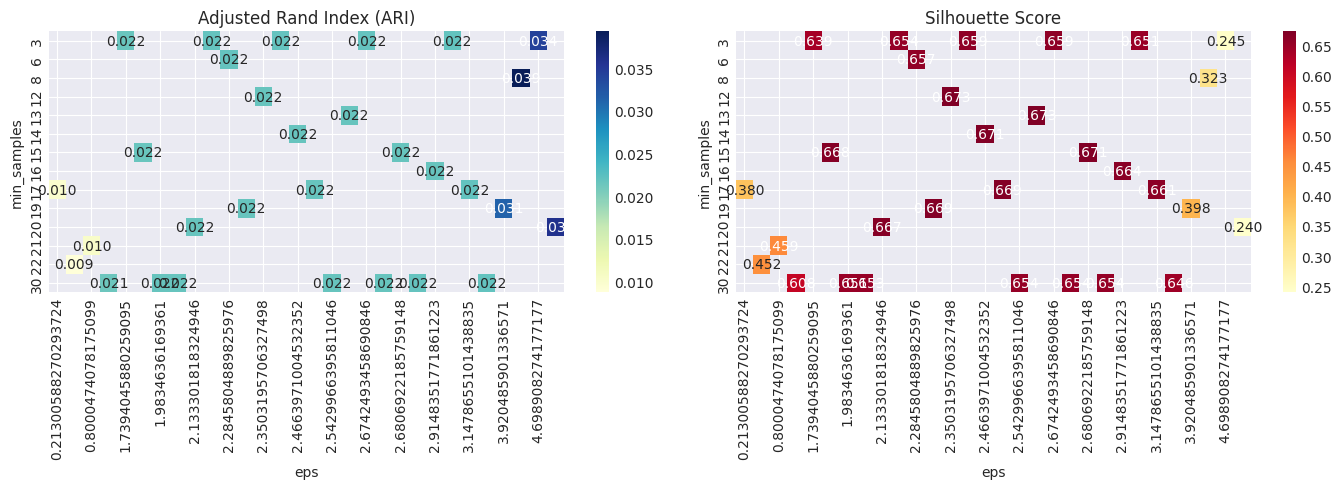

In [4]:
# Pivot results for heatmaps
def pivot_metric(df, metric):
    pivot = df.pivot(index='min_samples', columns='eps', values=metric)
    pivot = pivot.sort_index(ascending=True)
    return pivot

ari_pivot = pivot_metric(results_df, 'ARI')
sil_pivot = pivot_metric(results_df, 'silhouette')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ari_pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Adjusted Rand Index (ARI)')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('min_samples')

sns.heatmap(sil_pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('min_samples')

plt.tight_layout()
plt.show()

## Compare sklearn vs Custom DBSCAN with Best Parameters

Using the optimal parameters found via Bayesian optimization, we compare sklearn's DBSCAN against our custom implementation.

- `metric='manhattan'`: Faster distance computation

**Custom DBSCAN optimizations:**- `precompute=True`: Pre-calculates all pairwise distances (10-50x speedup)

SKLEARN vs CUSTOM DBSCAN COMPARISON

Using best parameters from Bayesian Optimization:
   eps = 2.3503
   min_samples = 12

⏳ Running sklearn DBSCAN (Manhattan)...


✅ sklearn DBSCAN: 59 clusters, 153 noise points

⏳ Running custom DBSCAN with provided pre-computed distance matrix...
   Using the same matrix as Bayesian optimization - no recomputation needed!
[DBSCAN] Using provided pre-computed distance matrix: shape (28432, 28432)
✅ Custom DBSCAN: 59 clusters, 153 noise points
   Execution time: 2114.48 seconds

PERFORMANCE COMPARISON

                n_clusters  n_noise       ARI      AMI  homogeneity  completeness  purity  silhouette
model                                                                                                
sklearn DBSCAN          59      153  0.021726  0.06781     0.152402      0.044133  0.6403    0.673441
Custom DBSCAN           59      153  0.021726  0.06781     0.152402      0.044133  0.6403    0.673441


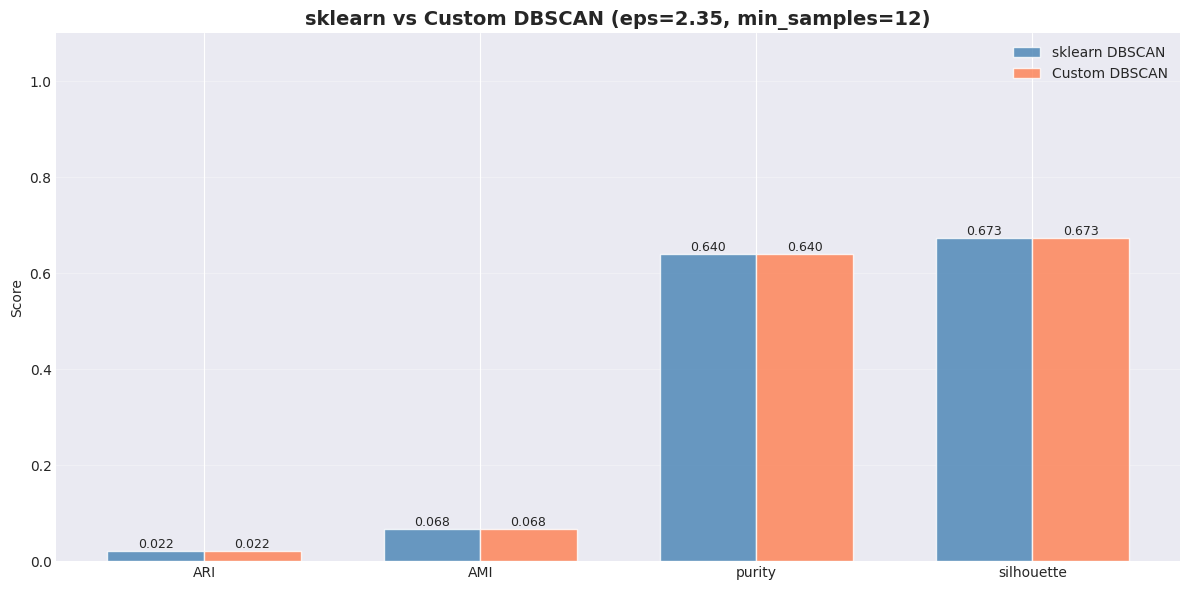


                n_clusters  n_noise
model                              
sklearn DBSCAN          59      153
Custom DBSCAN           59      153
Cluster counts and noise:


In [5]:
print("="*80)
print("SKLEARN vs CUSTOM DBSCAN COMPARISON")
print("="*80)
print(f"\nUsing best parameters from Bayesian Optimization:")
print(f"   eps = {best_eps:.4f}")
print(f"   min_samples = {best_min_samples}")

def evaluate_dbscan(model_name, labels):
    """Compute all metrics for given cluster labels."""
    n_clusters = len(np.unique(labels[labels != -1]))
    n_noise = int(np.sum(labels == -1))
    
    # If fewer than 2 clusters, metrics undefined
    if n_clusters < 2:
        return {
            'model': model_name, 'n_clusters': n_clusters, 'n_noise': n_noise,
            'ARI': np.nan, 'AMI': np.nan, 'homogeneity': np.nan,
            'completeness': np.nan, 'purity': np.nan, 'silhouette': np.nan
        }
    
    try:
        sil = silhouette_score(X, labels, metric='manhattan')  # Manhattan for consistency
    except:
        sil = np.nan
    
    ari = adjusted_rand_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels, average_method='arithmetic')
    hom = homogeneity_score(y_true, labels)
    comp = completeness_score(y_true, labels)
    
    # Purity
    purity = np.nan
    if n_clusters > 0:
        unique_clusters = np.unique(labels[labels != -1])
        cluster_purities = []
        for c in unique_clusters:
            members = y_true[labels == c]
            if len(members) > 0:
                most_common = np.bincount(members.astype(int)).max()
                cluster_purities.append(most_common)
        purity = np.sum(cluster_purities) / len(labels)
    
    return {
        'model': model_name, 'n_clusters': n_clusters, 'n_noise': n_noise,
        'ARI': ari, 'AMI': ami, 'homogeneity': hom,
        'completeness': comp, 'purity': purity, 'silhouette': sil
    }

# Train sklearn DBSCAN (Manhattan distance)
print("\n⏳ Running sklearn DBSCAN (Manhattan)...")
sklearn_dbscan = SklearnDBSCAN(eps=best_eps, min_samples=best_min_samples, metric='manhattan')
labels_sklearn = sklearn_dbscan.fit_predict(X)
metrics_sklearn = evaluate_dbscan('sklearn DBSCAN', labels_sklearn)
print(f"✅ sklearn DBSCAN: {metrics_sklearn['n_clusters']} clusters, {metrics_sklearn['n_noise']} noise points")

# Train custom DBSCAN with pre-computed distance matrix (Manhattan distance)
print("\n⏳ Running custom DBSCAN with provided pre-computed distance matrix...")
print("   Using the same matrix as Bayesian optimization - no recomputation needed!")
import time
start_time = time.time()
custom_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='manhattan', distance_matrix=dist_matrix)
labels_custom = custom_dbscan.fit_predict(X)
elapsed_time = time.time() - start_time
metrics_custom = evaluate_dbscan('Custom DBSCAN', labels_custom)
print(f"✅ Custom DBSCAN: {metrics_custom['n_clusters']} clusters, {metrics_custom['n_noise']} noise points")
print(f"   Execution time: {elapsed_time:.2f} seconds")

# Create comparison DataFrame
compare_df = pd.DataFrame([metrics_sklearn, metrics_custom]).set_index('model')

print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
print("\n" + compare_df.to_string())

# Visualize comparison
metrics_to_plot = ['ARI', 'AMI', 'purity', 'silhouette']
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_to_plot))
width = 0.35

vals_sklearn = [metrics_sklearn[m] for m in metrics_to_plot]
vals_custom = [metrics_custom[m] for m in metrics_to_plot]

bars1 = ax.bar(x - width/2, vals_sklearn, width, label='sklearn DBSCAN', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, vals_custom, width, label='Custom DBSCAN', alpha=0.8, color='coral')

ax.set_ylabel('Score')
ax.set_title(f'sklearn vs Custom DBSCAN (eps={best_eps:.2f}, min_samples={best_min_samples})', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("="*80)
print("\n" + "="*80)
print(compare_df[['n_clusters', 'n_noise']])
print("Cluster counts and noise:")

## Visual comparison of the distance metrics for the best parameters

Bar chart comparing ARI, AMI, Silhouette, Purity for Euclidean vs Manhattan

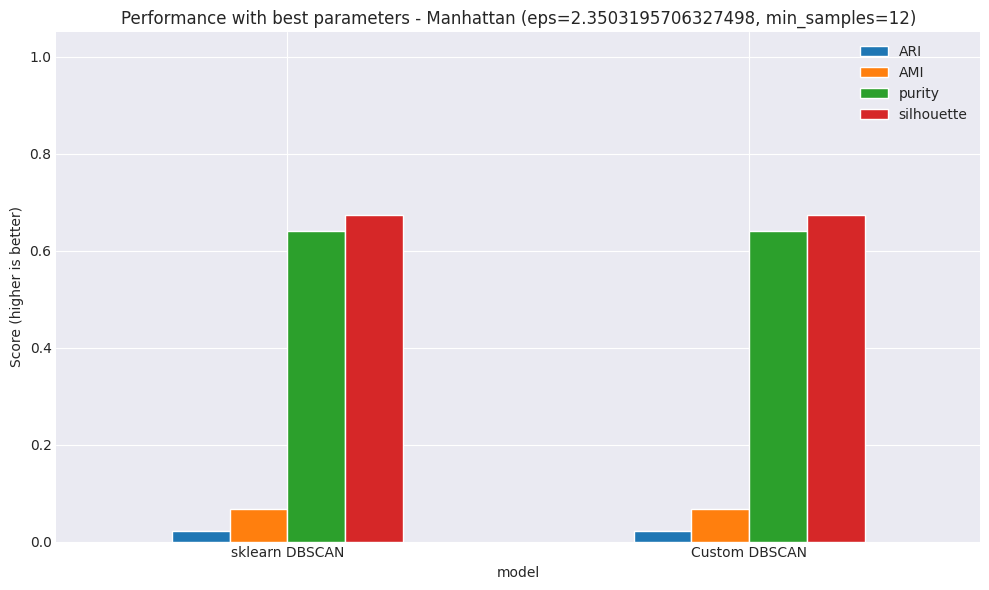

Cluster counts and noise
                n_clusters  n_noise
model                              
sklearn DBSCAN          59      153
Custom DBSCAN           59      153


In [6]:
metrics_to_plot = ['ARI','AMI','purity','silhouette']
vals = compare_df[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 6))
vals.plot(kind='bar', ax=ax)
ax.set_title(f'Performance with best parameters - Manhattan (eps={best_eps}, min_samples={best_min_samples})')
ax.set_ylabel('Score (higher is better)')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Show cluster counts for each metric
print('Cluster counts and noise')
print(compare_df[['n_clusters','n_noise']])

## Clustering Results Analysis

Now we analyze the clustering results in detail. **DBSCAN typically struggles with transitional/continuous data** like environmental features because:

1. **No clear density boundaries**: Fire risk features are continuous (temperature, precipitation, elevation) without sharp density gaps
2. **Uniform density**: Data points may be uniformly distributed, leading to either:
   - One giant cluster (if eps too large)
   - Many tiny clusters + lots of noise (if eps too small)
3. **Curse of dimensionality**: High-dimensional data makes density estimation unreliable

In [7]:
# =============================================================================
# DETAILED CLUSTERING ANALYSIS
# =============================================================================
from sklearn.decomposition import PCA

print("="*80)
print("CLUSTERING RESULTS ANALYSIS")
print("="*80)

# Use custom DBSCAN labels for analysis
labels = labels_custom
n_clusters = len(np.unique(labels[labels != -1]))
n_noise = np.sum(labels == -1)
noise_pct = 100 * n_noise / len(labels)

print(f"\n📊 CLUSTERING SUMMARY:")
print(f"   Total samples: {len(labels):,}")
print(f"   Number of clusters: {n_clusters}")
print(f"   Noise points: {n_noise:,} ({noise_pct:.1f}%)")

# Cluster size distribution
print(f"\n📈 CLUSTER SIZE DISTRIBUTION:")
unique_labels = np.unique(labels)
cluster_sizes = []
for label in sorted(unique_labels):
    size = np.sum(labels == label)
    if label == -1:
        print(f"   Noise (label=-1): {size:,} points ({100*size/len(labels):.1f}%)")
    else:
        cluster_sizes.append(size)
        print(f"   Cluster {label}: {size:,} points ({100*size/len(labels):.1f}%)")

if cluster_sizes:
    print(f"\n   Cluster size stats (excluding noise):")
    print(f"   - Min: {min(cluster_sizes):,}")
    print(f"   - Max: {max(cluster_sizes):,}")
    print(f"   - Mean: {np.mean(cluster_sizes):.1f}")
    print(f"   - Std: {np.std(cluster_sizes):.1f}")

# Class distribution within clusters
print(f"\n🔥 CLASS DISTRIBUTION WITHIN CLUSTERS:")
for label in sorted(unique_labels):
    mask = labels == label
    class_dist = y_true[mask]
    n_fire = np.sum(class_dist == 1)
    n_no_fire = np.sum(class_dist == 0)
    total = len(class_dist)
    label_name = "Noise" if label == -1 else f"Cluster {label}"
    print(f"   {label_name}: {n_fire} fire ({100*n_fire/total:.1f}%), {n_no_fire} no-fire ({100*n_no_fire/total:.1f}%)")

print("="*80)

CLUSTERING RESULTS ANALYSIS

📊 CLUSTERING SUMMARY:
   Total samples: 28,432
   Number of clusters: 59
   Noise points: 153 (0.5%)

📈 CLUSTER SIZE DISTRIBUTION:
   Noise (label=-1): 153 points (0.5%)
   Cluster 0: 7,717 points (27.1%)
   Cluster 1: 3,546 points (12.5%)
   Cluster 2: 6,267 points (22.0%)
   Cluster 3: 22 points (0.1%)
   Cluster 4: 2,357 points (8.3%)
   Cluster 5: 73 points (0.3%)
   Cluster 6: 422 points (1.5%)
   Cluster 7: 1,716 points (6.0%)
   Cluster 8: 2,058 points (7.2%)
   Cluster 9: 363 points (1.3%)
   Cluster 10: 292 points (1.0%)
   Cluster 11: 69 points (0.2%)
   Cluster 12: 46 points (0.2%)
   Cluster 13: 76 points (0.3%)
   Cluster 14: 413 points (1.5%)
   Cluster 15: 68 points (0.2%)
   Cluster 16: 309 points (1.1%)
   Cluster 17: 26 points (0.1%)
   Cluster 18: 64 points (0.2%)
   Cluster 19: 119 points (0.4%)
   Cluster 20: 74 points (0.3%)
   Cluster 21: 35 points (0.1%)
   Cluster 22: 196 points (0.7%)
   Cluster 23: 69 points (0.2%)
   Cluster 24: 

Visualizing clusters with PCA projection...


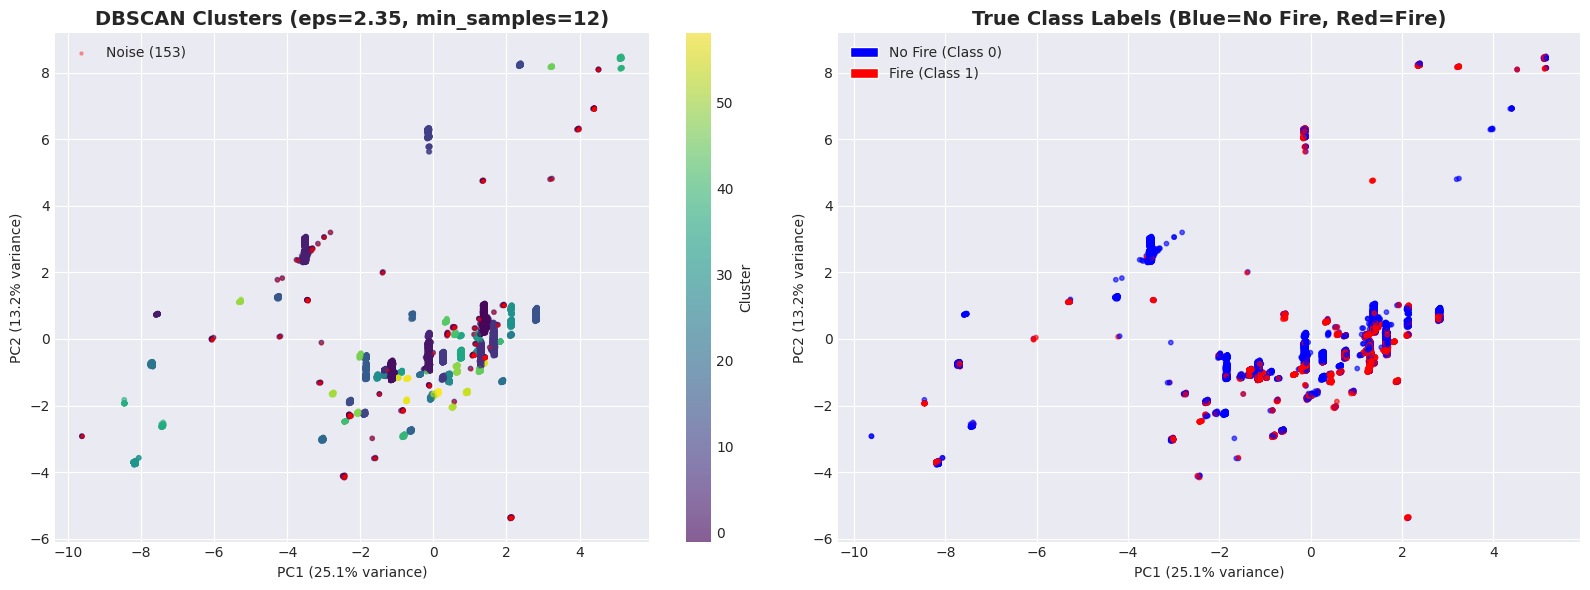


💡 OBSERVATION: Compare left (DBSCAN clusters) vs right (true labels)
   If clusters don't match true labels, DBSCAN may not be suitable for this data.


In [8]:
# =============================================================================
# VISUALIZATION 1: PCA Projection of Clusters
# =============================================================================
print("Visualizing clusters with PCA projection...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DBSCAN clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', 
                           s=10, alpha=0.6)
axes[0].set_title(f'DBSCAN Clusters (eps={best_eps:.2f}, min_samples={best_min_samples})', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Highlight noise points
noise_mask = labels == -1
if np.sum(noise_mask) > 0:
    axes[0].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                   c='red', s=5, alpha=0.3, label=f'Noise ({np.sum(noise_mask):,})')
    axes[0].legend()

# Plot 2: True class labels for comparison
colors = ['blue' if y == 0 else 'red' for y in y_true]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=10, alpha=0.6)
axes[1].set_title('True Class Labels (Blue=No Fire, Red=Fire)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='No Fire (Class 0)'),
                   Patch(facecolor='red', label='Fire (Class 1)')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print(f"\n💡 OBSERVATION: Compare left (DBSCAN clusters) vs right (true labels)")
print("   If clusters don't match true labels, DBSCAN may not be suitable for this data.")

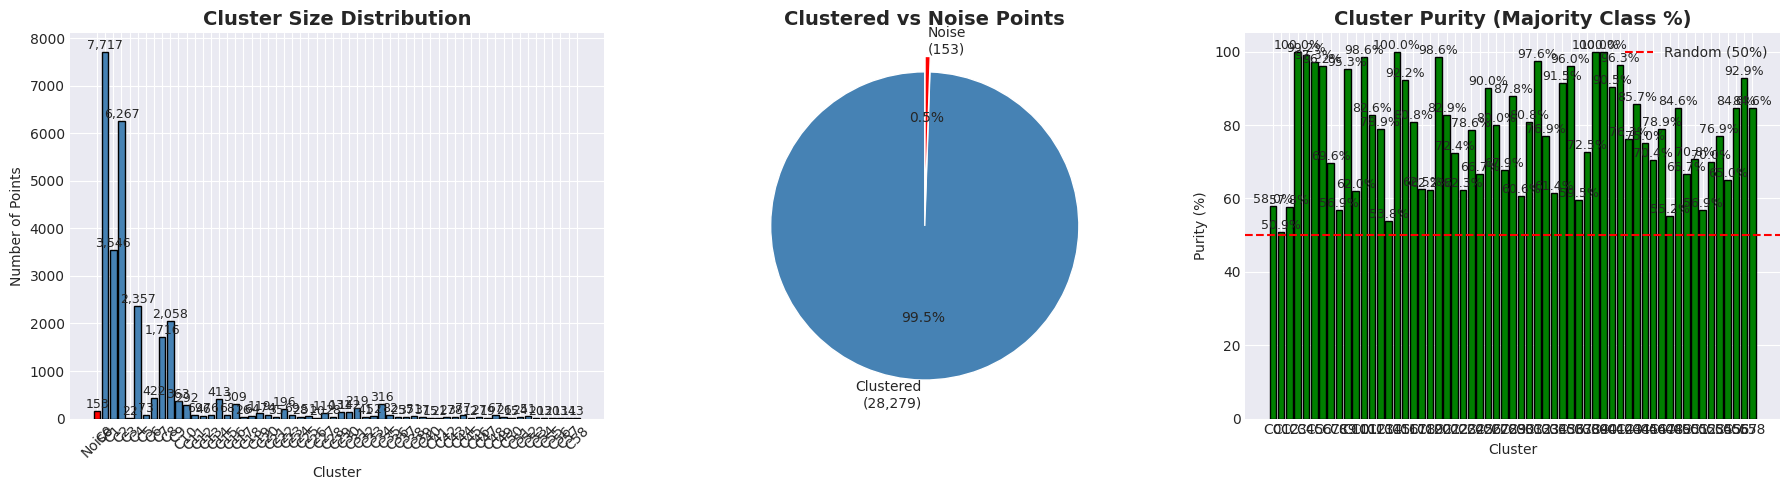

In [9]:
# =============================================================================
# VISUALIZATION 2: Cluster Size Distribution & Noise Analysis
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Cluster size bar chart
unique_labels_sorted = sorted([l for l in np.unique(labels)])
sizes = [np.sum(labels == l) for l in unique_labels_sorted]
colors = ['red' if l == -1 else 'steelblue' for l in unique_labels_sorted]
label_names = ['Noise' if l == -1 else f'C{l}' for l in unique_labels_sorted]

bars = axes[0].bar(label_names, sizes, color=colors, edgecolor='black')
axes[0].set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Points')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for bar, size in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{size:,}', ha='center', va='bottom', fontsize=9)

# Plot 2: Pie chart of cluster vs noise
if n_noise > 0:
    pie_sizes = [len(labels) - n_noise, n_noise]
    pie_labels = [f'Clustered\n({len(labels)-n_noise:,})', f'Noise\n({n_noise:,})']
    pie_colors = ['steelblue', 'red']
    axes[1].pie(pie_sizes, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%',
               startangle=90, explode=(0, 0.1))
    axes[1].set_title('Clustered vs Noise Points', fontsize=14, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No noise points', ha='center', va='center', fontsize=14)
    axes[1].set_title('Clustered vs Noise Points', fontsize=14, fontweight='bold')

# Plot 3: Class purity per cluster
cluster_purities = []
cluster_labels_plot = []
for label in sorted([l for l in np.unique(labels) if l != -1]):
    mask = labels == label
    class_dist = y_true[mask]
    majority_pct = 100 * max(np.sum(class_dist == 0), np.sum(class_dist == 1)) / len(class_dist)
    cluster_purities.append(majority_pct)
    cluster_labels_plot.append(f'C{label}')

if cluster_purities:
    bars = axes[2].bar(cluster_labels_plot, cluster_purities, color='green', edgecolor='black')
    axes[2].axhline(y=50, color='red', linestyle='--', label='Random (50%)')
    axes[2].set_title('Cluster Purity (Majority Class %)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Cluster')
    axes[2].set_ylabel('Purity (%)')
    axes[2].set_ylim(0, 105)
    axes[2].legend()
    
    # Add value labels
    for bar, purity in zip(bars, cluster_purities):
        axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{purity:.1f}%', ha='center', va='bottom', fontsize=9)
else:
    axes[2].text(0.5, 0.5, 'No clusters found', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

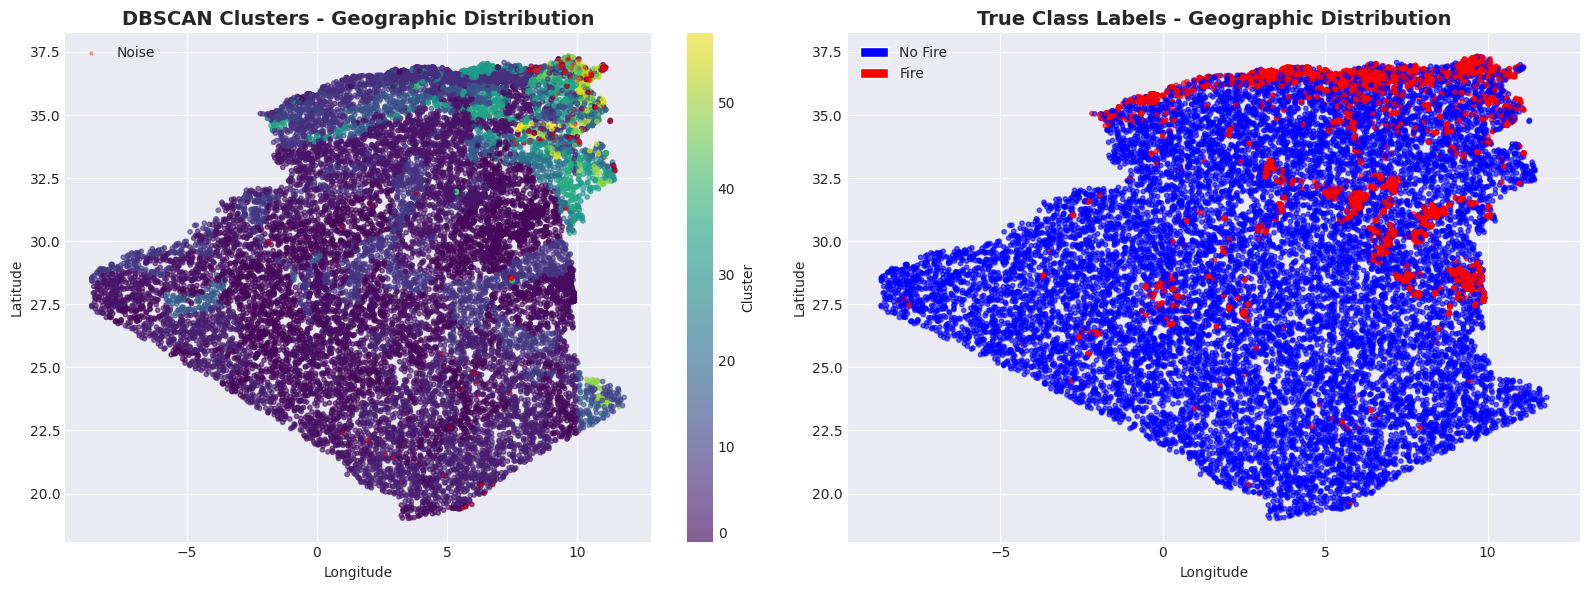

In [10]:
# =============================================================================
# VISUALIZATION 3: Geographic Distribution of Clusters
# =============================================================================
# Reload original data to get coordinates
df_with_coords = pd.read_csv(FIRES_ENGINEERED_TOP15_UNSUPERVISED)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters on geographic map
scatter1 = axes[0].scatter(df_with_coords['longitude'], df_with_coords['latitude'], 
                           c=labels, cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('DBSCAN Clusters - Geographic Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Highlight noise
if np.sum(noise_mask) > 0:
    axes[0].scatter(df_with_coords.loc[noise_mask, 'longitude'], 
                   df_with_coords.loc[noise_mask, 'latitude'],
                   c='red', s=5, alpha=0.3, label='Noise')
    axes[0].legend()

# Plot 2: True labels on geographic map
colors = ['blue' if y == 0 else 'red' for y in y_true]
axes[1].scatter(df_with_coords['longitude'], df_with_coords['latitude'], 
               c=colors, s=10, alpha=0.6)
axes[1].set_title('True Class Labels - Geographic Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

legend_elements = [Patch(facecolor='blue', label='No Fire'),
                   Patch(facecolor='red', label='Fire')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## Conclusions: Why DBSCAN May Struggle with Fire Data

Based on the analysis above, DBSCAN typically shows poor performance on fire prediction data because:

### Expected Issues:
1. **High noise percentage**: Most points classified as noise (not belonging to any cluster)
2. **Single dominant cluster**: One large cluster containing most non-noise points
3. **Low cluster purity**: Clusters contain mixed fire/no-fire points (close to 50%)
4. **Poor ARI/AMI scores**: Clusters don't correspond to actual fire/no-fire classes

### Why This Happens:
- **Transitional data**: Environmental features (temperature, precipitation, elevation) vary continuously
- **No clear density gaps**: Fire and non-fire regions overlap in feature space
- **Curse of dimensionality**: With many features, density-based clustering becomes unreliable

### Recommendations:
- **Use supervised methods** (Random Forest, KNN) for fire prediction - they're designed for classification
- **Try K-Means** for unsupervised clustering - it doesn't rely on density
- **Feature selection** might help DBSCAN by reducing dimensionality
- **DBSCAN is better suited** for anomaly detection or finding outliers in the data